<h1> B Data Reduction </h1>

# Importing libraries

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact
import numpy as np
import warnings
import statistics as stt
import os
from scipy import stats
from scipy.optimize import curve_fit
from numpy import arange
from collections import deque
import string

# Functions

In [2]:
#-------------------------------
# Loading & select different type of data, z.b B, C, U
#-------------------------------

def dirFiles(fDir, ending):
    fNames = []
    for i in os.listdir(fDir):
        if i.endswith(ending):
            fNames.append(i)
    return fNames

#-------------------------------
# used for mapping
#-------------------------------

def selSmpType(dataFiles):
    l = []
    for file in dataFiles:    
        l.append(float(file.split('_')[0]))
    return l

#-------------------------------
# Outlier Correction and Data Conversion from str to float
#-------------------------------
def outlierCorrection(measurement, factorSD):
    element_signal = np.array(measurement)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    return [x for x in measurement if (x > mean - factorSD * sd) and (x < mean + factorSD * sd)]

#-------------------------------
# background substact for 10B with the average of 9.9 and 10.2, think abut each line has to be connected
#-------------------------------

def bacground_sub(folder, select_line, factorSD, factor_B11):
    listname = dirFiles('/Users/mila/Documents/GitHub/boron-main/data/' + folder, 'exp')
    listname.sort()
    average_B = []
    for filename in listname:
        #read data
        df = pd.read_csv('/Users/mila/Documents/GitHub/boron-main/data/' +folder + '/' +filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
        #read all data rows and select useful columns
        fil = df['10B'].str.contains('L|IC|C|H') == True
        endnum = df['10B'][fil].index[0]
        df_data = df[:endnum][['9.9', '10B', '10.2', '11B']].astype(float)
            #seperate two dataframe based on selectline, one is background, one is signal 
        index_select = df_data['10B'] >= select_line
        df_bacground_mean = df_data[~index_select].mean()
        df_signal = df_data.loc[index_select]
            #substract background, substract bulc for 10B and 11B
        df_bacground_sub = df_signal - df_bacground_mean
        df_bacground_sub['10B_bulc_sub'] = df_bacground_sub['10B']-(df_bacground_sub['9.9']+df_bacground_sub['10.2'])/2
        df_bacground_sub['11B_bulc_sub'] = df_bacground_sub['11B']-factor_B11*(df_bacground_sub['9.9']+df_bacground_sub['10.2'])/2
        df_bacground_sub['11B/10B'] = df_bacground_sub['11B_bulc_sub']/df_bacground_sub['10B_bulc_sub'] 

        res = outlierCorrection(df_bacground_sub['11B/10B'], factorSD)
        average_B.append({'filename': filename, '11B/10B_row': np.mean(res), 'se': np.std(res)})
    return (pd.DataFrame(average_B))


#-------------------------------
# regression based on the level from 2-5 you chosed
#-------------------------------

def polynomFit(inp, *args):
    x=inp
    res=0
    for order in range(len(args)):
        res+=args[order] * x**order
    return res


def regression(x, y, ref_stand, order, listname):
    fig, ax = plt.subplots()
    ax.plot(x, y, label='measuered', marker='o', linestyle='none' )
    x_use = np.array(x)
    popt, pcov = curve_fit(polynomFit, xdata=x_use, ydata=y , p0=[0]*(order+1))
    fitData=polynomFit(x_use,*popt)
    ax.plot(x_use, fitData, label='polyn. fit, order '+str(order), linestyle='--' )
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    
    res = []
    for unknown in listname:
        y_unknown = ref_stand / polynomFit(unknown,*popt)
        res.append({'factor': y_unknown})
    return(pd.DataFrame(res))

# machine drift correction and isotope results calculations

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


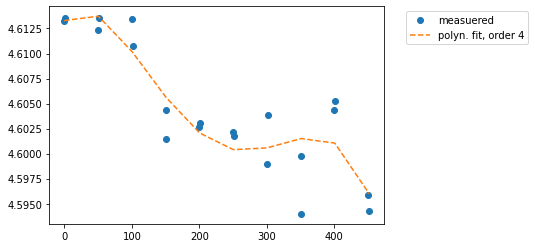

In [131]:
#background substraction
df_data = bacground_sub('2022-11-28 B Carb Sy MC JX AG splitstream_20221128-203622', 0.01, 2, 1)
#Choose A to get the regression for drift correction
fil = df_data['filename'].str.contains('A')
df_data_A = df_data[fil]
df_data['filenamber'] = selSmpType(df_data['filename'])

y = df_data_A['11B/10B_row']
x = df_data_A.index.to_numpy()
#get the regression function and get all corrected factors for all measurements
factor = regression(x,y, 4.05, 4, df_data.index.to_numpy())

#use corrected factors to correct machine drift and calculate isotope values for results
df_data['factor'] = factor
df_data['11B/10B_corrected'] = df_data['factor']*df_data['11B/10B_row']
df_data['δ11B'] = ((df_data['11B/10B_corrected']/4.055)-1)*1000
df_data['δ11B_se'] = (df_data['se']*df_data['factor']/4.055)*1000

# Mapping: Laser parameters and isotope results

In [140]:
#read laser file
df_Laser = pd.read_csv('data/seq1_log_20221128_203700.csv', header=0)
#select useful information from Laser file
res = []
for i in df_data['filenamber']:
    mapping = df_Laser[df_Laser[' Sequence Number']==i].index[0]
    df_data_laser = df_Laser.loc[mapping, [' Laser Energy (mJ)', ' Laser HV (kV)', ' Spot Size (um)', ' Comment']]
    res.append(df_data_laser)
#combine laser file and isotopic results
df_data_laser = pd.DataFrame(res).reset_index()
df_final = pd.concat([df_data_laser, df_data], axis = 1)
columns_origine = df_final.columns
#change sequence of all columns
df_final = df_final.reindex(columns=['index','filename', ' Comment', ' Spot Size (um)', 
'11B/10B_row', 'se', 'filenamber', 'factor','11B/10B_corrected', 'δ11B', 'δ11B_se', 
                                     ' Laser Energy (mJ)', ' Laser HV (kV)'])

df_final

,index,filename,Comment,Spot Size (um),11B/10B_row,se,filenamber,factor,11B/10B_corrected,δ11B,δ11B_se,Laser Energy (mJ),Laser HV (kV)
0,0,001_A.exp,NIST nnp,90.0,4.613279,0.011116,1.0,0.877910,4.050045,-1.221880,2.406550,75.140,24.360
1,5,002_A.exp,NIST nnp,193.0,4.613548,0.009760,2.0,0.877896,4.050217,-1.179532,2.112935,75.048,24.700
2,10,003_B.exp,B5 nnP,193.0,4.585033,0.010473,3.0,0.877883,4.025123,-7.368061,2.267396,75.328,24.761
3,15,004_B.exp,B5 nnP,285.0,4.585159,0.007716,4.0,0.877870,4.025174,-7.355398,1.670346,74.544,24.788
4,20,005_C.exp,MACS,285.0,4.583599,0.013240,5.0,0.877858,4.023749,-7.706831,2.866379,74.786,24.759
...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,2345,470_U.exp,NaN,130.0,4.594984,0.009251,470.0,0.881913,4.052376,-0.647145,2.011970,74.448,24.620
470,2350,471_U.exp,NaN,130.0,4.602634,0.010369,471.0,0.881960,4.059337,1.069512,2.255189,74.631,24.628
471,2355,472_U.exp,NaN,130.0,4.601562,0.010235,472.0,0.882007,4.058610,0.890176,2.226193,74.578,24.583
472,2360,473_U.exp,NaN,130.0,4.600368,0.010546,473.0,0.882055,4.057778,0.685069,2.294089,75.239,24.630


# Testing

In [13]:
results = {'Laser Energy (mJ)': res_energy, 
           'Spot Size (um)': res_spotsize, 'Laser HV (kV)': res_HV}

Laser_res= pd.DataFrame(results)
resss = pd.concat([Laser_res, dfN.reindex(Laser_res.index)], axis=1)

NameError: name 'res_energy' is not defined

In [14]:
def laser_Cond(smp):
    return resss[resss['sequence'].str.contains(smp)]

laser_Cond('A')

NameError: name 'resss' is not defined

### Some old code

In [ ]:
#check for outliers for signal:
    element_signal = np.array(fils)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    final_list_signal = [x for x in fils if (x > mean - factorSD * sd)]
    final_list_signal = [x for x in final_list_signal if (x < mean + factorSD * sd)]
    
#check for outliers for background:
    element_backg = np.array(filw)
    mean = np.mean(element_backg, axis=0)
    sd = np.std(element_backg, axis=0)
    final_list_backg = [x for x in filw if (x > mean - factorSD * sd)]
    final_list_backg = [x for x in final_list_backg if (x < mean + factorSD * sd)]
    

def calculateSingleFile(filename, bg_10B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-02-15 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:
    endnum = df['10B'][df['10B'] == 'L3'].index[0]
#    B_10 = []
    fils = []
    filw = []
#    for i in df['10B'][0:endnum]:
#        B_10.append(float(i)) #conversion to float required, as numbers are stored as str
#    for i in B_10:
    for i in df['10B'][0:endnum]:
        meas = float(i)
        if (meas > bg_10B) == True:
            fils.append(meas)
        else:
            filw.append(meas)

#    outlier_corrected_signal =outlierCorrection(fils, factorSD)
#    outlier_corrected_backg =outlierCorrection(filw, factorSD)

#    B_10_aver = sum(outlier_corrected_signal )/len(outlier_corrected_signal )
#    B_10_backg_aver = sum(outlier_corrected_backg)/len(outlier_corrected_backg)

    B_10_aver = np.mean(outlierCorrection(fils, factorSD))
    B_10_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    
    return(B_10_aver, B_10_backg_aver)


def background_substract_basic(filename, signal_object, select_line, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:

    data_float = data_convert(df[signal_object]) #conversion to float required, as numbers are stored as str
    fils = []
    filw = []
        
    for i in data_float:
        if (i > select_line) == True:
            fils.append(i)
        else:
            filw.append(i)

    signal_aver = np.mean(outlierCorrection(fils, factorSD))
    backg_aver = np.mean(outlierCorrection(filw, factorSD))
    res = signal_aver - backg_aver
    return(res)


def background_substract_interference_bacground(filename, select_line, factorSD, factor_B11):
    
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
    res_bacg_inter_sub = []
    data_interference_left = data_convert(df['9.9'])
    data_interference_right = data_convert(df['10.2'])
    data_B10 = data_convert(df['10B'])
    data_B11 = data_convert(df['11B'])

    bacgrounds = []
    bacgrounds_10 = []
    bacgrounds_11 = []
    bacgrounds_99 = []
    bacgrounds_102 = []
    for i in data_B10:
        if (i < select_line) == True:
            index = data_B10.index(i)
            j = data_B11[index]
            bacgrounds_10.append(i)
            bacgrounds_11.append(j)
            bacgrounds_99.append(i)
            bacgrounds_102.append(j)
    backg10_aver = np.mean(outlierCorrection(bacgrounds_10, factorSD))        
    backg11_aver = np.mean(outlierCorrection(bacgrounds_11, factorSD))        
    backg99_aver = np.mean(outlierCorrection(bacgrounds_10, factorSD))
    backg102_aver = np.mean(outlierCorrection(bacgrounds_102, factorSD))

    for i in data_B10:
        if (i > select_line) == True:
            index = data_convert(df['10B']).index(i)
            interference_left_back_sub = data_interference_left[index] - backg99_aver
            interference_right_back_sub = data_interference_right[index] - backg102_aver
            interference = (interference_left_back_sub + interference_right_back_sub)/2
            res_10 = i - interference - backg10_aver
            res_11 = data_B11[index] - (interference * factor_B11) - backg11_aver
            #offset = res_11/res_10 - 
            res_bacg_inter_sub.append (res_11/res_10)

        res = outlierCorrection(res_bacg_inter_sub, factorSD)
    return np.mean(res)


#-------------------------------
#background substact with the basic method, signal_aver-background_aver
#-------------------------------

def background_substract_basic(filename, signal_object, select_line, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#read all data rows and select useful columns
    fil = df['10B'].str.contains('L|IC|C|H') == True
    endnum = df['10B'][fil].index[0]
    df_data = df[:endnum][['10B', '11B']].astype(float)
#seperate two dataframe based on selectline, one is background, one is signal 
    index_select = df_data[signal_object] >= select_line
    df_bacground_mean = df_data[~filx].mean()
    df_signal = df_data.loc[index_select]
#substract background, substract bulc for 10B and 11B
    df_bacground_sub = df_signal - df_bacground.mean()                            
    res = outlierCorrection(df_bacground_sub['11B']/df_bacground_sub['10B'], factorSD)
    return(res)



dataFiles = dirFiles('data/2022-11-04 Boron measurements', 'exp')
dataFiles.sort()

dataFiles = selSmpType('B')

dataFiles

res = []
for i in dataFiles:
    aver = background_substract_basic(i, '11B', 0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
    Neptune_res = {'sequence': i, 'average':aver}
    res.append(Neptune_res)

x_b = getfilenumber(pd.DataFrame(res)['sequence'], '_')

#def offset(datafile):
 #   res = []
  #  for i in datafile:
   #     res.append(objective(i, a, b, c, d, e, f))
    #return res

#offset(x_b)
res = []
for i in dataFiles:
    aver = background_substract_basic(i, '11B', 0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
    Neptune_res = {'sequence': i, 'average':aver}
    res.append(Neptune_res)
res




def data_convert(data):
    data_float = []
    fil =  (data.str.contains('L|IC|C|H') == True)
    endnum = data[fil].index[0]
    for i in data[0:endnum]:
        data_float.append(float(i))
    return data_float




def selSmpType(dataFiles, smp):
    l = []
    for file in dataFiles:    
        if smp in file.split('_')[1]:
            l.append(file)
    return l

#-------------------------------
# read the number from Neptune filename
#-------------------------------

def getfilenumber(datafile, simbel):
    res = []
    for i in datafile:
        res.append(float(i.split(simbel)[0]))
    return res


#-------------------------------
# average valye calculation
#-------------------------------
def calculate_aver(dataFiles, IC):
    res = []
    for i in dataFiles:
        aver = background_substract_basic(i, '11B',  0.005, 2)/background_substract_basic(i, '10B', 0.0005, 2)
        Neptune_res = {'sequence': i, 'average':aver}
        res.append(Neptune_res)
        df = pd.DataFrame(res)
        
    return df
